In [ ]:
%matplotlib inline
import lightkurve as lk
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from astropy.timeseries import LombScargle
import astropy.units as u

target_list = pd.read_csv("complete_targets_KIDS_correct.csv")

Go through the first light curve of every star and grab the quarter, period, and power.

In [ ]:
i = 0

target_list = pd.read_csv("complete_targets_KIDS_correct.csv")

for idx, row in target_list.iterrows():
    kepler_id = row["Kepler ID"]

    i=i+1
    print(i)
    if i % 250 == True: 
        target_list.to_csv("40daylimit_periods.csv", index=False)

    if pd.isna(kepler_id):
        continue

    try: 
        search_result = lk.search_lightcurve(f"KIC {int(kepler_id)}", author='Kepler')

        lc = search_result.download()    
        target_list.at[idx, "LC1 Quarter"] = lc.quarter

        time = lc.time.value if hasattr(lc.time, "value") else np.asarray(lc.time)
        flux = lc.flux.value if hasattr(lc.flux, "value") else np.asarray(lc.flux)

        mask = np.isfinite(time) & np.isfinite(flux)
        time = time[mask]
        flux = flux[mask]

        frequency, power = LombScargle(time, flux).autopower(minimum_frequency=1/40, maximum_frequency=10)
        peak_frequency = frequency[np.argmax(power)]
        peak_period = 1 / peak_frequency
        peak_power = power[np.argmax(power)]

        target_list.at[idx, "LC1 Period"] = peak_period
        target_list.at[idx, "LC1 Power"] = peak_power
    
    except Exception as e:
        print(f"⚠️ Skipping KIC {kepler_id}: {e}")
        continue

# Save updated CSV
target_list.to_csv("40daylimit_periods.csv", index=False)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277


c:\Users\avery\OneDrive\Documents\GitHub\Astro502\.venv\Lib\site-packages\lightkurve\search.py:420: LightkurveWarning: Warning: 18 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(
c:\Users\avery\OneDrive\Documents\GitHub\Astro502\.venv\Lib\site-packages\lightkurve\search.py:420: LightkurveWarning: Warning: 18 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(
c:\Users\avery\OneDrive\Documents\GitHub\Astro502\.venv\Lib\site-packages\lightkurve\search.py:420: LightkurveWarning: Warning: 9 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.wa

1367
1368
1369
1370
1371
1372


c:\Users\avery\OneDrive\Documents\GitHub\Astro502\.venv\Lib\site-packages\lightkurve\search.py:420: LightkurveWarning: Warning: 9 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(
c:\Users\avery\OneDrive\Documents\GitHub\Astro502\.venv\Lib\site-packages\lightkurve\search.py:420: LightkurveWarning: Warning: 17 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(
c:\Users\avery\OneDrive\Documents\GitHub\Astro502\.venv\Lib\site-packages\lightkurve\search.py:420: LightkurveWarning: Warning: 17 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.wa

1373
1374
1375
1376
1377


...

4229


c:\Users\avery\OneDrive\Documents\GitHub\Astro502\.venv\Lib\site-packages\lightkurve\search.py:420: LightkurveWarning: Warning: 14 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(
c:\Users\avery\OneDrive\Documents\GitHub\Astro502\.venv\Lib\site-packages\lightkurve\search.py:420: LightkurveWarning: Warning: 14 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


4230
4231
4232
4233


c:\Users\avery\OneDrive\Documents\GitHub\Astro502\.venv\Lib\site-packages\lightkurve\search.py:420: LightkurveWarning: Warning: 17 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(
c:\Users\avery\OneDrive\Documents\GitHub\Astro502\.venv\Lib\site-packages\lightkurve\search.py:420: LightkurveWarning: Warning: 17 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


4234
4235
4236
4237
4238
4239
4240
4241
4242
4243
4244
4245
4246
4247
4248
4249
4250
4251
4252
4253
4254
4255
4256
4257
4258
4259
4260
4261
4262
4263
4264
4265
4266
4267
4268
4269
4270
4271
4272
4273
4274
4275
4276
4277
4278
4279
4280
4281
4282
4283
4284
4285
4286
4287
4288
4289
4290
4291
4292
4293
4294
4295
4296
4297
4298
4299
4300
4301
4302
4303
4304
4305
4306
4307
4308
4309
4310
4311
4312
4313
4314
4315
4316
4317
4318
4319
4320
4321
4322
4323
4324
4325
4326
4327
4328
4329
4330
4331
4332
4333
4334
4335
4336
4337
4338
4339
4340
4341
4342
4343
4344
4345
4346
4347
4348
4349
4350
4351
4352
4353
4354
4355
4356
4357
4358
4359
4360
4361
4362
4363
4364
4365
4366
4367
4368
4369
4370
4371
4372
4373
4374
4375
4376
4377
4378
4379
4380
4381
4382
4383
4384
4385
4386
4387
4388
4389
4390
4391
4392
4393
4394
4395
4396
4397
4398
4399
4400
4401
4402
4403
4404
4405
4406
4407
4408
4409
4410
4411
4412
4413
4414
4415
4416
4417
4418
4419
4420
4421
4422
4423
4424
4425
4426
4427
4428
4429
4430
4431
4432
4433


Go through all light curves for each star, not just the first. 

In [ ]:
i = 0

target_list = pd.read_csv("40daylimit_periods.csv")

for idx, row in target_list.iterrows():
    kepler_id = row["Kepler ID"]

    i=i+1
    print(i)
    if i % 50 == True: 
        target_list.to_csv("70daylimit_allperiods", index=False)

    if pd.isna(kepler_id):
        continue

    try: 
        search_result = lk.search_lightcurve(f"KIC {int(kepler_id)}", author='Kepler')

        for lc_idx, lc_entry in enumerate(search_result):
            lc = lc_entry.download()    
            target_list.at[idx, f"LC{lc_idx+1} Quarter"] = lc.quarter

            time = lc.time.value if hasattr(lc.time, "value") else np.asarray(lc.time)
            flux = lc.flux.value if hasattr(lc.flux, "value") else np.asarray(lc.flux)

            mask = np.isfinite(time) & np.isfinite(flux)
            time = time[mask]
            flux = flux[mask]

            frequency, power = LombScargle(time, flux).autopower(minimum_frequency=1/70, maximum_frequency=10)
            peak_frequency = frequency[np.argmax(power)]
            peak_period = 1 / peak_frequency
            peak_power = power[np.argmax(power)]

            target_list.at[idx, f"LC{lc_idx+1} Period"] = peak_period
            target_list.at[idx, f"LC{lc_idx+1} Power"] = peak_power
    
    except Exception as e:
        print(f"⚠️ Skipping KIC {kepler_id}: {e}")
        continue

# Save updated CSV
target_list.to_csv("70daylimit_allperiods", index=False)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277


C:\Users\avery\AppData\Local\Temp\ipykernel_12756\848907082.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  target_list.at[idx, f"LC{lc_idx+1} Period"] = peak_period
C:\Users\avery\AppData\Local\Temp\ipykernel_12756\848907082.py:36: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  target_list.at[idx, f"LC{lc_idx+1} Power"] = peak_power
C:\Users\avery\AppData\Local\Temp\ipykernel_12756\848907082.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has

1396
1397
1398


C:\Users\avery\AppData\Local\Temp\ipykernel_12756\848907082.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  target_list.at[idx, f"LC{lc_idx+1} Quarter"] = lc.quarter
C:\Users\avery\AppData\Local\Temp\ipykernel_12756\848907082.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  target_list.at[idx, f"LC{lc_idx+1} Period"] = peak_period
C:\Users\avery\AppData\Local\Temp\ipykernel_12756\848907082.py:36: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which h

1399
1400
1401
1402
1403
1404
1405
1406


C:\Users\avery\AppData\Local\Temp\ipykernel_12756\848907082.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  target_list.at[idx, f"LC{lc_idx+1} Quarter"] = lc.quarter
C:\Users\avery\AppData\Local\Temp\ipykernel_12756\848907082.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  target_list.at[idx, f"LC{lc_idx+1} Period"] = peak_period
C:\Users\avery\AppData\Local\Temp\ipykernel_12756\848907082.py:36: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which h

1407
1408
1409
1410
1411
1412
1413
1414
1415
1416
1417
1418
1419
1420
1421
1422
1423
1424
1425
1426
1427
1428
1429
1430
1431
1432
1433
1434
1435
1436
1437
1438
1439
1440
1441
1442
1443
1444
1445
1446
1447
1448
1449
1450
1451
1452
1453
1454
1455
1456
1457
1458
1459
1460
1461
1462
1463
1464
1465
1466
1467
1468
1469
1470
1471
1472
1473
1474
1475
1476
1477
1478
1479
1480
1481
1482
1483
1484
1485
1486
1487
1488
1489
1490
1491
1492
1493
1494
1495
1496
1497
1498
1499
1500
1501
1502
1503
1504
1505
1506
1507
1508
1509
1510
1511
1512
1513
1514
1515
1516
1517
1518
1519
1520
1521
1522
1523
1524
1525
1526
1527
1528
1529
1530
1531
1532
1533
1534
1535
1536
1537
1538
1539
1540
1541
1542
1543
1544
1545
1546
1547
1548
1549
1550
1551
1552
1553
1554
1555
1556
1557
1558
1559
1560
1561
1562
1563
1564
1565
1566
1567
1568
1569
1570
1571
1572
1573
1574
1575
1576
1577
1578
1579
1580
1581
1582
1583
1584
1585
1586
1587
1588
1589
1590
1591
1592
1593
1594
1595
1596
1597
1598
1599
1600
1601
1602
1603
1604
1605
1606


C:\Users\avery\AppData\Local\Temp\ipykernel_12756\848907082.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  target_list.at[idx, f"LC{lc_idx+1} Quarter"] = lc.quarter
C:\Users\avery\AppData\Local\Temp\ipykernel_12756\848907082.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  target_list.at[idx, f"LC{lc_idx+1} Period"] = peak_period
C:\Users\avery\AppData\Local\Temp\ipykernel_12756\848907082.py:36: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which h

3019
3020
3021
3022
3023
3024
3025
3026
3027
3028
3029
3030
3031
3032
3033
3034
3035
3036
3037
3038
3039
3040
3041
3042
3043
3044
3045
3046
3047
3048
3049
3050
3051
3052
3053
3054
3055
3056
3057
3058
3059
3060
3061
3062
3063
3064
3065
3066
3067
3068
3069
3070
3071
3072
3073
3074
3075
3076
3077
3078
3079
3080
3081
3082
3083
3084
3085
3086
3087
3088
3089
3090
3091
3092
3093
3094
3095
3096
3097
3098
3099
3100
3101
3102
3103
3104
3105
3106
3107
3108
3109
3110
3111
3112
3113
3114
3115
3116
3117
3118
3119
3120
3121
3122
3123
3124
3125
3126
3127
3128
3129
3130
3131
3132
3133
3134
3135
3136
3137
3138
3139
3140
3141
3142
3143
3144
3145
3146
3147
3148
3149
3150
3151
3152
3153
3154
3155
3156
3157
3158
3159
3160
3161
3162
3163
3164
3165
3166
3167
3168
3169
3170
3171
3172
3173
3174
3175
3176
3177
3178
3179
3180
3181
3182
3183
3184
3185
3186
3187
3188
3189
3190
3191
3192
3193
3194
3195
3196
3197
3198
3199
3200
3201
3202
3203
3204
3205
3206
3207
3208
3209
3210
3211
3212
3213
3214
3215
3216
3217
3218


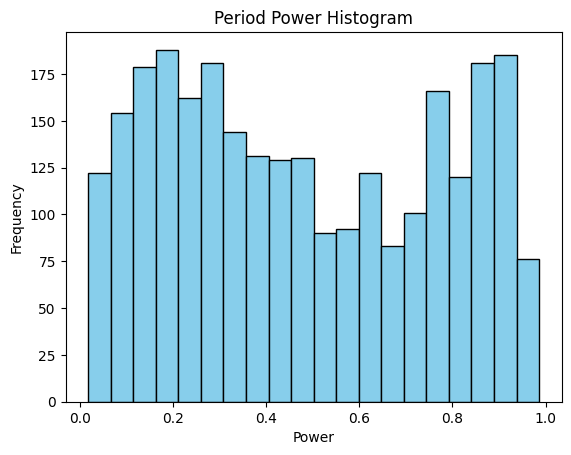

In [ ]:
target_list = pd.read_csv("best_periods_unchecked.csv")
data = target_list["Best Power"]

plt.hist(data, bins=20, color='skyblue', edgecolor='black')

# Adding labels and title
plt.xlabel('Power')
plt.ylabel('Frequency')
plt.title('Period Power Histogram')

# Display the plot
plt.show()